# Photon Defect Array Demo

This notebook demonstrates a dark-field photon-count image built from a 10x10 defect array. The defects are bright points on a low photon background. The defect FWHM decreases from left to right so the size trend is visually obvious. All physical lengths below are in micrometers.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / "src"))

from fourier_optics import gaussian_defect_library, photon_defect_array

output_dir = repo_root / "outputs"
output_dir.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 130})

## Demo Parameters

This demo keeps the matrix small enough for ordinary interactive use: `2200 um x 2048 um` at `2 um/pixel`, about one megapixel. The image is dark-field: low background, bright defect signal. `poisson_sample` is the switch for photon shot-noise sampling.

In [2]:
defect_names = [f"def{i}" for i in range(1, 11)]

params = {
    "pixel_size": 2.0,
    "size_x": 2200.0,
    "size_y": 2048.0,
    "grid_shape": (10, 10),
    "pitch": 160.0,
    "defect_size_x": 120.0,
    "defect_size_y": 120.0,
    "photon_def": 12000.0,
    "photon_bkg": 20.0,
    "poisson_sample": True,
    "rng_seed": 7,
    "column_defects": defect_names,
    # Left to right: increasingly smaller bright defects.
    "fwhm_by_name": {name: fwhm for name, fwhm in zip(defect_names, np.linspace(70.0, 8.0, 10))},
}

params

{'pixel_size': 2.0,
 'size_x': 2200.0,
 'size_y': 2048.0,
 'grid_shape': (10, 10),
 'pitch': 160.0,
 'defect_size_x': 120.0,
 'defect_size_y': 120.0,
 'photon_def': 12000.0,
 'photon_bkg': 20.0,
 'poisson_sample': True,
 'rng_seed': 7,
 'column_defects': ['def1',
  'def2',
  'def3',
  'def4',
  'def5',
  'def6',
  'def7',
  'def8',
  'def9',
  'def10'],
 'fwhm_by_name': {'def1': 70.0,
  'def2': 63.111111111111114,
  'def3': 56.22222222222222,
  'def4': 49.33333333333333,
  'def5': 42.44444444444444,
  'def6': 35.55555555555556,
  'def7': 28.666666666666664,
  'def8': 21.77777777777777,
  'def9': 14.888888888888886,
  'def10': 8.0}}

## Build Photon Image

In [3]:
defs = gaussian_defect_library(
    params["fwhm_by_name"],
    pixel_size=params["pixel_size"],
    defect_size_x=params["defect_size_x"],
    defect_size_y=params["defect_size_y"],
)

photon_image = photon_defect_array(
    defs=defs,
    pixel_size=params["pixel_size"],
    photon_def=params["photon_def"],
    photon_bkg=params["photon_bkg"],
    size_x=params["size_x"],
    size_y=params["size_y"],
    column_defects=params["column_defects"],
    pitch=params["pitch"],
    grid_shape=params["grid_shape"],
    max_pixels=2_000_000,
    poisson_sample=params["poisson_sample"],
    rng_seed=params["rng_seed"],
)

print(f"photon_image shape: {photon_image.shape}")
print(f"memory: {photon_image.nbytes / 1024**2:.2f} MiB")
print(f"min / max photons: {photon_image.min():.1f} / {photon_image.max():.1f}")
print(f"poisson_sample: {params['poisson_sample']}")

photon_image shape: (1024, 1100)
memory: 8.59 MiB
min / max photons: 3.0 / 12292.0
poisson_sample: True


## Full Target View

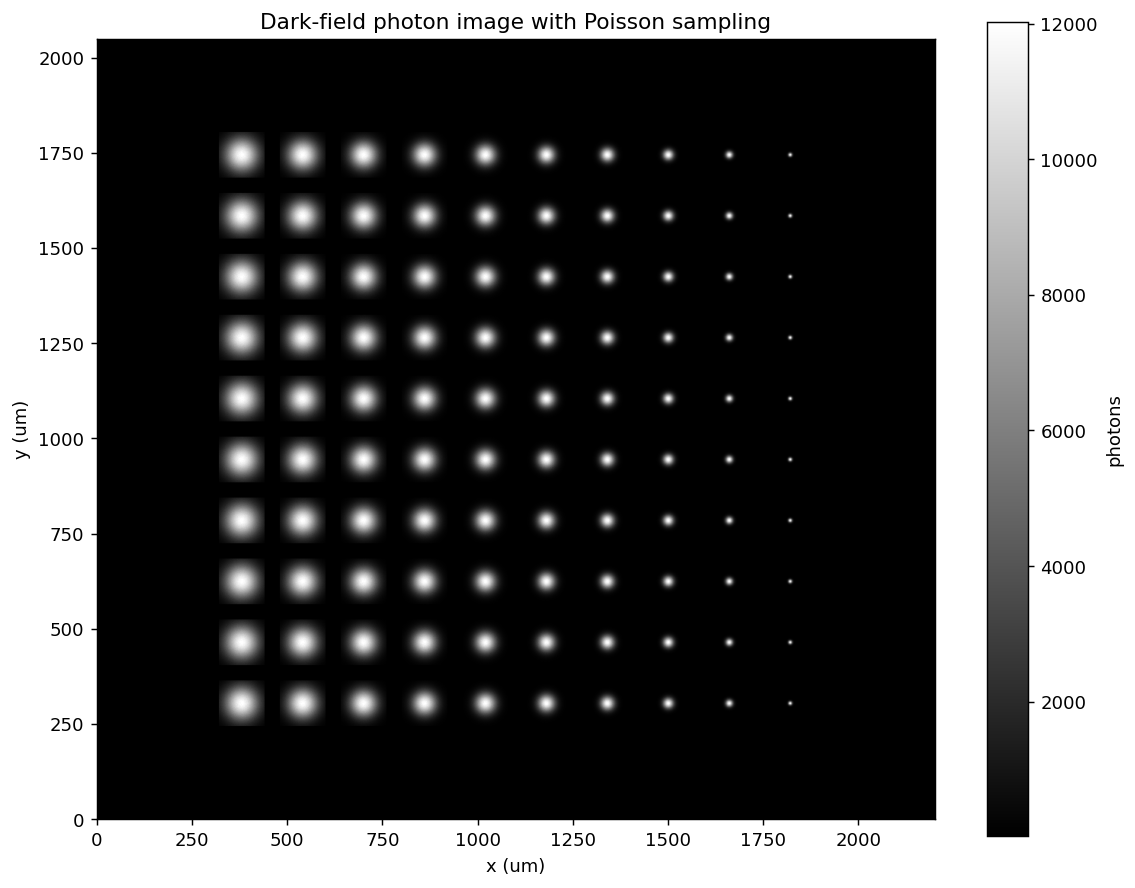

outputs/photon_defect_array_demo_full_gray.png


In [4]:
extent = [0, params["size_x"], 0, params["size_y"]]
full_png = output_dir / "photon_defect_array_demo_full_gray.png"

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    photon_image,
    cmap="gray",
    origin="lower",
    extent=extent,
    vmin=params["photon_bkg"] - 5,
    vmax=params["photon_bkg"] + params["photon_def"],
)
ax.set_title("Dark-field photon image with Poisson sampling")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
fig.colorbar(im, ax=ax, label="photons")
fig.tight_layout()
fig.savefig(full_png, dpi=180)
plt.show()
print(full_png.relative_to(repo_root))

![Full gray photon image](../outputs/photon_defect_array_demo_full_gray.png)

## Zoomed Defect Array

The zoom makes the left-to-right shrinkage clear. Each column uses one defect type, from `def1` on the left to `def10` on the right.

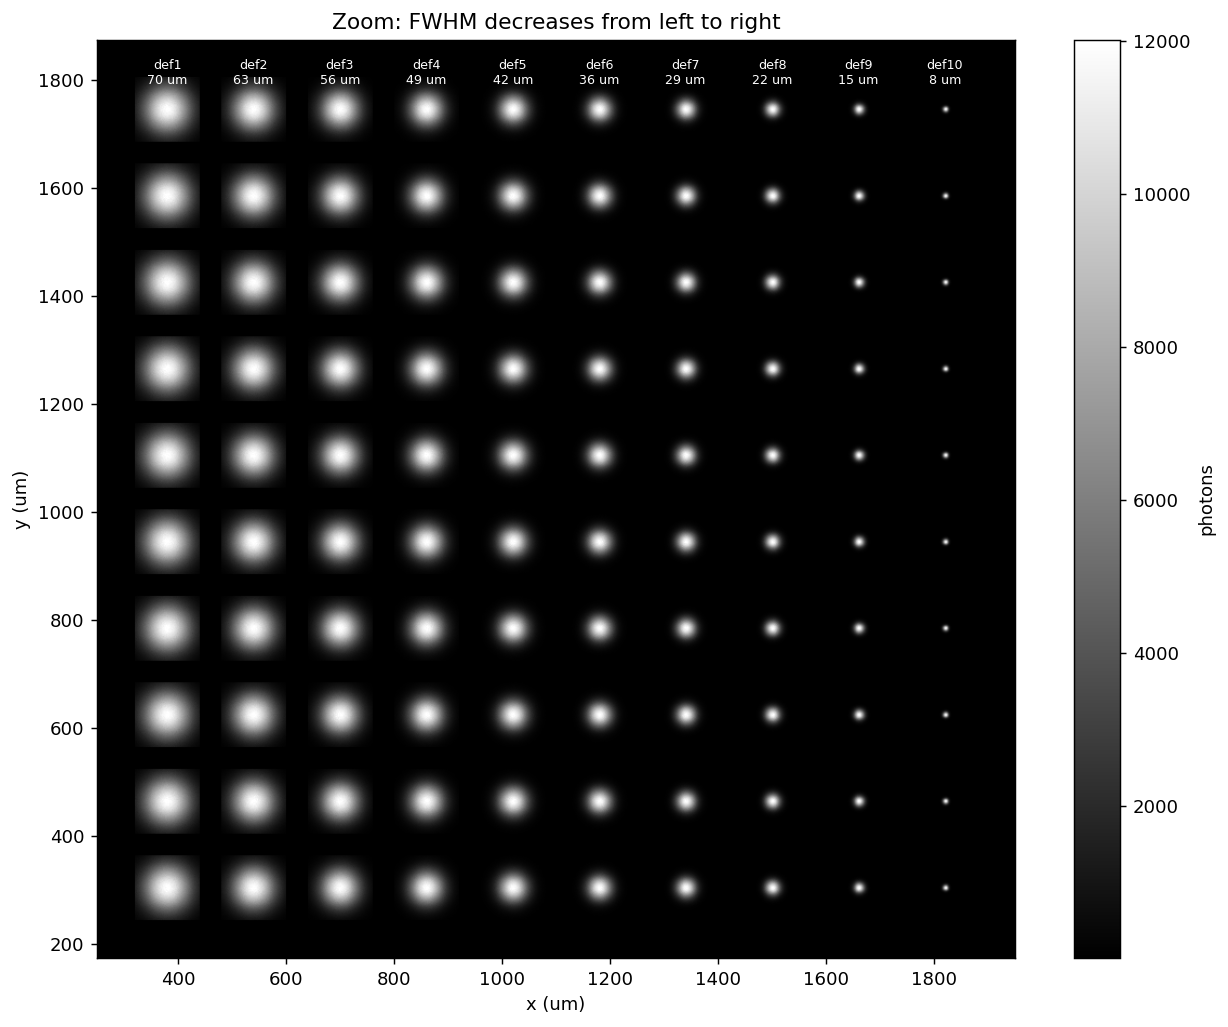

outputs/photon_defect_array_demo_zoom_gray.png


In [5]:
rows, cols = params["grid_shape"]
center_x = params["size_x"] / 2
center_y = params["size_y"] / 2
span_x = (cols - 1) * params["pitch"] + params["defect_size_x"] + 140.0
span_y = (rows - 1) * params["pitch"] + params["defect_size_y"] + 140.0
zoom_extent = [
    center_x - span_x / 2,
    center_x + span_x / 2,
    center_y - span_y / 2,
    center_y + span_y / 2,
]
zoom_png = output_dir / "photon_defect_array_demo_zoom_gray.png"

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    photon_image,
    cmap="gray",
    origin="lower",
    extent=extent,
    vmin=params["photon_bkg"] - 5,
    vmax=params["photon_bkg"] + params["photon_def"],
)
ax.set_xlim(zoom_extent[0], zoom_extent[1])
ax.set_ylim(zoom_extent[2], zoom_extent[3])
ax.set_title("Zoom: FWHM decreases from left to right")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")

x_positions = center_x + (np.arange(cols) - (cols - 1) / 2) * params["pitch"]
y_label = zoom_extent[3] - 35
for name, x in zip(params["column_defects"], x_positions):
    ax.text(
        x,
        y_label,
        f"{name}\n{params['fwhm_by_name'][name]:.0f} um",
        color="white",
        ha="center",
        va="top",
        fontsize=7,
    )
fig.colorbar(im, ax=ax, label="photons")
fig.tight_layout()
fig.savefig(zoom_png, dpi=180)
plt.show()
print(zoom_png.relative_to(repo_root))

![Zoomed gray photon image](../outputs/photon_defect_array_demo_zoom_gray.png)

## Central Row Profile

A row through the middle of the array shows photon shot noise and progressively narrower peaks from left to right.

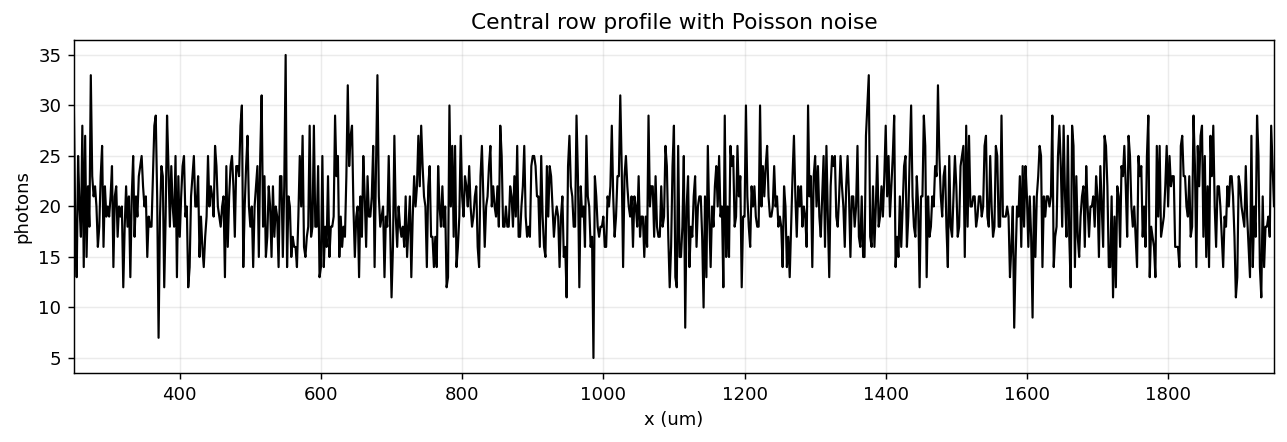

outputs/photon_defect_array_demo_profile.png


In [6]:
center_row = photon_image.shape[0] // 2
x_um = np.arange(photon_image.shape[1]) * params["pixel_size"]
profile_png = output_dir / "photon_defect_array_demo_profile.png"

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(x_um, photon_image[center_row], color="black", linewidth=1.2)
ax.set_xlim(zoom_extent[0], zoom_extent[1])
ax.set_xlabel("x (um)")
ax.set_ylabel("photons")
ax.set_title("Central row profile with Poisson noise")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(profile_png, dpi=180)
plt.show()
print(profile_png.relative_to(repo_root))

![Central row profile](../outputs/photon_defect_array_demo_profile.png)